# Análise das Regiões que possuem as Maiores Rentabilidades

In [7]:
# Importa a biblioteca pandas para manipulação de dados
import pandas as pd
# Importa a biblioteca matplotlib para visualização de gráficos
import matplotlib.pyplot as plt
# Importa a biblioteca seaborn para visualização de gráficos mais avançados
import seaborn as sns
# Importa SparkSession para iniciar e gerenciar sessões Spark
from pyspark.sql import SparkSession
# Importa pathlib para iniciar e gerenciar caminhos de arquivos
from pathlib import Path
# Importa funções Spark para manipulação de colunas e expressões SQL
import pyspark.sql.functions as f

# Funções

In [8]:
def read_csv_dataset(path:str):
  """
  Read a csv file and return a pandas dataframe.
  ---
  path: string with the path to the csv file
  ---
  returns: pandas dataframe
  """
  return pd.read_csv(path)

def create_spark_df(spark_session, df:pd.DataFrame):
  return spark_session.createDataFrame(df)

def execute_sql(query:str, spark_session):
  return spark_session.sql(query)

In [9]:
# Cria ou obtém uma sessão Spark. Isso é necessário para trabalhar com DataFrames Spark e SQL.
spark_session = SparkSession.builder.getOrCreate()

In [10]:
# Define os caminhos para os arquivos CSV dos datasets de pedidos, itens e clientes.
orders_items_path = '../data/olist_order_items_dataset.csv'
orders_path = '../data/olist_orders_dataset.csv'
customers_path = '../data/olist_customers_dataset.csv'

In [11]:
import pandas as pd

def read_csv_dataset(path:str):
  """
  Lê um arquivo CSV e retorna um DataFrame pandas.
  ---
  path: string com o caminho para o arquivo CSV
  ---
  returns: pandas DataFrame
  """
  return pd.read_csv(path)

def create_spark_df(spark_session, df:pd.DataFrame):
  """
  Converte um DataFrame pandas em um DataFrame Spark.
  ---
  spark_session: A sessão Spark ativa
  df: DataFrame pandas a ser convertido
  ---
  returns: Spark DataFrame
  """
  return spark_session.createDataFrame(df)

def execute_sql(query:str, spark_session):
  """
  Executa uma query SQL usando a sessão Spark e retorna um DataFrame Spark.
  ---
  query: string com a query SQL a ser executada
  spark_session: A sessão Spark ativa
  ---
  returns: Spark DataFrame resultante da query
  """
  return spark_session.sql(query)

## Items

In [12]:
# Carrega o dataset de itens de pedido usando a função 'read_csv_dataset'
items = read_csv_dataset(orders_items_path)
# Converte o DataFrame pandas 'items' em um DataFrame Spark
items = create_spark_df(spark_session, items)

In [ ]:
# ============================================================
# ACESSO AO GOOGLE DRIVE (APENAS PARA USO NO GOOGLE COLAB)
# ============================================================

# Este bloco é utilizado quando o notebook é executado no Google Colab.
# Ele permite montar o Google Drive e acessar arquivos armazenados na sua conta.

# No ambiente local (VS Code / Jupyter local), NÃO é necessário utilizar esse código,
# pois os arquivos já estão disponíveis diretamente na estrutura de pastas do projeto.

# Se estiver rodando no Google Colab:
# 1. Descomente as linhas abaixo
# 2. Execute a célula
# 3. Autorize o acesso ao seu Google Drive
# 4. Ajuste os caminhos dos arquivos para apontar para o diretório dentro do Drive

# from google.colab import drive
# drive.mount('/content/drive')

## Orders

In [14]:
# Carrega o dataset de pedidos usando a função 'read_csv_dataset'
orders = read_csv_dataset(orders_path)
# Converte o DataFrame pandas 'orders' em um DataFrame Spark
orders = create_spark_df(spark_session, orders)

## Customers

In [15]:
# Carrega o dataset de clientes usando a função 'read_csv_dataset'
customers = read_csv_dataset(customers_path)
# Converte o DataFrame pandas 'customers' em um DataFrame Spark
customers = create_spark_df(spark_session, customers)

## Transforming spark datasets into views to use SQL on them

In [16]:
# Garante que os DataFrames existem e recria as views temporárias
items.createOrReplaceTempView("fat_items")
orders.createOrReplaceTempView("fat_orders")
customers.createOrReplaceTempView("dim_customers")
if 'products' in globals():
    products.createOrReplaceTempView("dim_products")

## Merging tables to make only one df

In [17]:
# Query SQL para juntar os DataFrames de itens, pedidos e clientes.
# Filtra apenas os pedidos com status 'delivered' (entregue) para garantir dados relevantes para a análise de lucro.
query = """
SELECT i.*, o.*, c.*
FROM fat_items i
INNER JOIN fat_orders o ON o.order_id = i.order_id
INNER JOIN dim_customers c ON c.customer_id = o.customer_id
WHERE o.order_status = 'delivered'
"""

# Executa a query SQL e armazena o resultado em um novo DataFrame Spark chamado 'df'
df = execute_sql(query, spark_session)

# Exibe as primeiras 20 linhas do DataFrame resultante, com 'truncate=False' para mostrar o conteúdo completo das colunas.
df.show(truncate=False)

+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+------+-------------+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------------------+--------------------------------+------------------------+-------------------+--------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |shipping_limit_date|price |freight_value|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city      |customer_state|
+---------

In [18]:
# Adiciona uma coluna 'total_cost' arredondando o valor do frete (freight_value) para 3 casas decimais.
df = df.withColumn(
    "total_cost",
    f.round(f.col("freight_value"),3)
)

# Adiciona uma coluna 'profit' (lucro) calculando a diferença entre o preço do item e o custo total do frete,
# arredondando o resultado para 3 casas decimais.
df = df.withColumn(
    "profit",
    f.round(f.col("price") - f.col("total_cost"),3)
)

# Adiciona uma coluna 'profitability' (rentabilidade) calculando a porcentagem do lucro em relação ao preço do item,
# arredondando o resultado para 3 casas decimais e multiplicando por 100.
df = df.withColumn(
    "profitability",
    f.round(f.col("profit") / f.col("price"),3) * 100
)

In [19]:
# Agrupa o DataFrame 'df' pelo estado do cliente ('customer_state') e calcula a soma total do lucro ('profit') para cada estado.
# O resultado é armazenado em um novo DataFrame Spark 'df_profits', com a coluna de soma renomeada para 'profit_sum'.
df_profits = df.groupBy("customer_state") \
  .agg(f.sum("profit").alias("profit_sum"))

# Exibe o DataFrame 'df_profits' mostrando a soma do lucro por estado.
df_profits.show()

+--------------+------------------+
|customer_state|        profit_sum|
+--------------+------------------+
|            SC| 418896.4800000001|
|            RO|          34399.52|
|            PI|          64263.81|
|            AM|          16726.21|
|            RR|           5075.42|
|            GO|231461.05000000002|
|            TO|          36797.65|
|            MT|123158.81999999998|
|            SP|  4365563.16999999|
|            PB| 87335.09000000003|
|            ES|219628.96999999986|
|            RS| 596322.1500000001|
|            MS| 96492.38999999993|
|            AL|63538.950000000026|
|            MG|1286071.9900000042|
|            PA|         136917.61|
|            BA| 396030.4699999996|
|            SE|42859.250000000015|
|            PE|         194806.93|
|            CE|173077.98999999996|
+--------------+------------------+
only showing top 20 rows



In [20]:
# Converte o DataFrame Spark 'df_profits' para um DataFrame pandas para facilitar a visualização com Matplotlib/Seaborn.
df_profits = df_profits.toPandas()

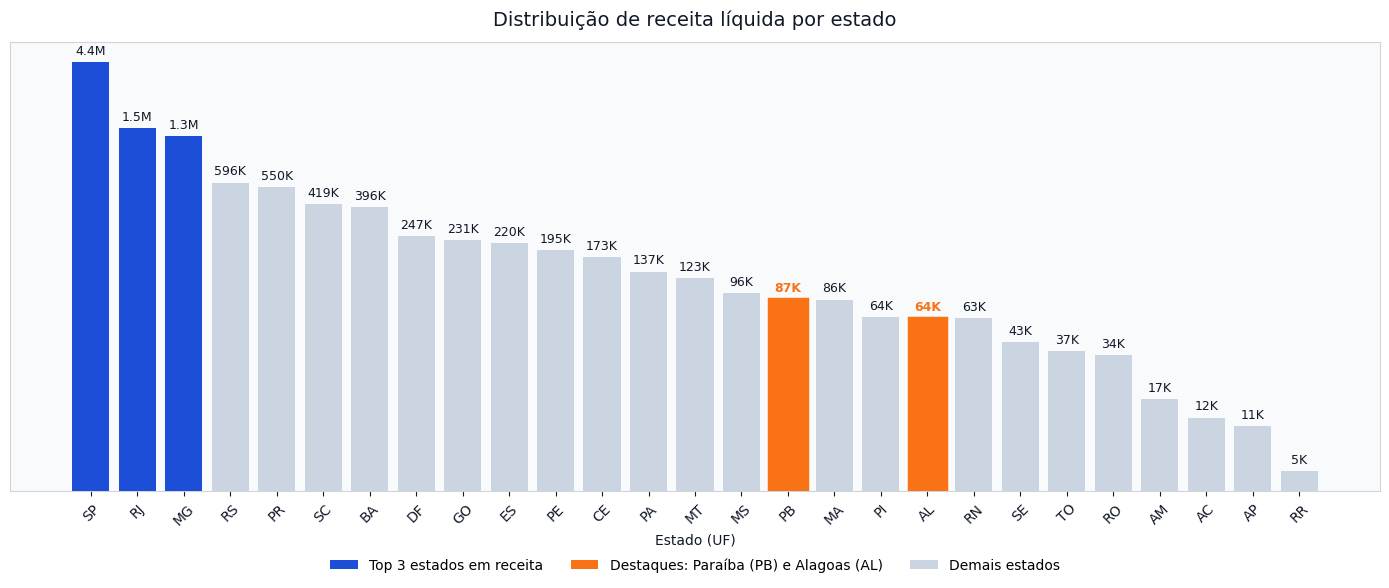

In [21]:
# ============================================================
# GRÁFICO: RENTABILIDADE PROXY POR ESTADO
# ============================================================

cor_figura = "#FFFFFF"
cor_fundo = "#F9FAFB"
cor_texto = "#111827"
cor_grid = "#D1D5DB"

cor_top3 = "#1D4ED8"
cor_destaque = "#F97316"
cor_demais = "#CBD5E1"

# ------------------------------------------------------------
# Ordenar valores
# ------------------------------------------------------------
df_profits = df_profits.sort_values("profit_sum", ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# Estados em destaque
# ------------------------------------------------------------
estados_destaque = ["PB", "AL"]

# ------------------------------------------------------------
# Definir cores
# ------------------------------------------------------------
cores = []

for i, row in df_profits.iterrows():
    estado = row["customer_state"]

    if i < 3:
        cores.append(cor_top3)          # Top 3 em receita
    elif estado in estados_destaque:
        cores.append(cor_destaque)      # PB e AL
    else:
        cores.append(cor_demais)        # Demais estados

# ------------------------------------------------------------
# Função para formatar valores
# ------------------------------------------------------------
def format_profit(value):
    if value >= 1_000_000:
        return f"{value/1e6:.1f}M"
    if value >= 1_000:
        return f"{value/1e3:.0f}K"
    return f"{value:.0f}"

# ------------------------------------------------------------
# Criar figura
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
bars = ax.bar(
    df_profits["customer_state"],
    df_profits["profit_sum"],
    color=cores,
    edgecolor="none",
    zorder=3
)

# Escala logarítmica para lidar com grande diferença entre estados
ax.set_yscale("log")
ax.yaxis.set_visible(False)

# ------------------------------------------------------------
# Título e eixos
# ------------------------------------------------------------
ax.set_title(
    "Distribuição de receita líquida por estado",
    fontsize=14,
    color=cor_texto,
    pad=12
)

ax.set_xlabel("Estado (UF)", color=cor_texto)
ax.set_ylabel("Rentabilidade proxy", color=cor_texto)

# ------------------------------------------------------------
# Labels nas barras
# ------------------------------------------------------------
for bar, estado in zip(bars, df_profits["customer_state"]):
    altura = bar.get_height()

    cor_label = cor_destaque if estado in estados_destaque else cor_texto
    peso_label = "bold" if estado in estados_destaque else "normal"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura * 1.08,
        format_profit(altura),
        ha="center",
        va="bottom",
        fontsize=9,
        color=cor_label,
        fontweight=peso_label
    )

# ------------------------------------------------------------
# Destacar borda de PB e AL
# ------------------------------------------------------------
for bar, estado in zip(bars, df_profits["customer_state"]):
    if estado in estados_destaque:
        bar.set_edgecolor(cor_destaque)
        bar.set_linewidth(2.5)

# ------------------------------------------------------------
# Legenda
# ------------------------------------------------------------
from matplotlib.patches import Patch

legenda = [
    Patch(facecolor=cor_top3, label="Top 3 estados em receita"),
    Patch(facecolor=cor_destaque, label="Destaques: Paraíba (PB) e Alagoas (AL)"),
    Patch(facecolor=cor_demais, label="Demais estados")
]

ax.legend(
    handles=legenda,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False,
    fontsize=10
)

# ------------------------------------------------------------
# Grid, eixos e bordas
# ------------------------------------------------------------
ax.grid(axis="y", linestyle="--", alpha=0.25, color=cor_grid, zorder=0)
ax.tick_params(axis="x", colors=cor_texto, rotation=45)

for spine in ax.spines.values():
    spine.set_color(cor_grid)

plt.tight_layout()
plt.show()

In [23]:
# Define o caminho para o arquivo CSV do dataset de produtos.
products_path = '../data/olist_products_dataset.csv'
# Carrega o dataset de produtos usando a função 'read_csv_dataset'.
products = read_csv_dataset(products_path)
# Converte o DataFrame pandas 'products' em um DataFrame Spark.
products = create_spark_df(spark_session, products)
# Cria uma view temporária para o DataFrame Spark 'products', chamada 'dim_products', para uso em queries SQL.
products.createOrReplaceTempView("dim_products")
print("Products dataset loaded and view created.")

Products dataset loaded and view created.


In [24]:
# Query SQL para juntar os DataFrames de itens, pedidos, clientes e agora também produtos.
# Inclui a categoria do produto ('product_category_name') na seleção.
# Filtra apenas os pedidos com status 'delivered' (entregue).
query_with_products = """
SELECT i.*, o.*, c.*, p.product_category_name
FROM fat_items i
INNER JOIN fat_orders o ON o.order_id = i.order_id
INNER JOIN dim_customers c ON c.customer_id = o.customer_id
INNER JOIN dim_products p ON p.product_id = i.product_id
WHERE o.order_status = 'delivered'
"""
# Executa a query SQL e armazena o resultado em um novo DataFrame Spark 'df_with_products'.
df_with_products = execute_sql(query_with_products, spark_session)

# Adiciona uma coluna 'total_cost' arredondando o valor do frete para 3 casas decimais.
df_with_products = df_with_products.withColumn(
    "total_cost",
    f.round(f.col("freight_value"),3)
)

# Adiciona uma coluna 'profit' (lucro) calculando a diferença entre o preço do item e o custo total do frete,
# arredondando o resultado para 3 casas decimais.
df_with_products = df_with_products.withColumn(
    "profit",
    f.round(f.col("price") - f.col("total_cost"),3)
)

# Adiciona uma coluna 'profitability' (rentabilidade) calculando a porcentagem do lucro em relação ao preço do item,
# arredondando o resultado para 3 casas decimais e multiplicando por 100.
df_with_products = df_with_products.withColumn(
    "profitability",
    f.round(f.col("profit") / f.col("price"),3) * 100
)

print("DataFrame with products and profit metrics created.")
# Exibe as primeiras 20 linhas do DataFrame resultante, com 'truncate=False' para mostrar o conteúdo completo das colunas.
df_with_products.show(truncate=False)

DataFrame with products and profit metrics created.
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+------+-------------+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+--------------------------------+--------------------------------+------------------------+--------------+--------------+---------------------+----------+-------+-----------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |shipping_limit_date|price |freight_value|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|customer_id                    

In [25]:
# Agrupa o DataFrame 'df_with_products' pelo estado do cliente ('customer_state') e pela categoria do produto ('product_category_name').
# Calcula a soma total do lucro ('profit') para cada combinação de estado e categoria.
# Ordena os resultados em ordem decrescente pela soma do lucro ('profit_sum').
df_profits_by_state_category = df_with_products.groupBy("customer_state", "product_category_name") \
  .agg(f.sum("profit").alias("profit_sum")) \
  .orderBy(f.col("profit_sum").desc())

print("Profits by state and product category:")
# Exibe as primeiras 20 linhas do DataFrame resultante, com 'truncate=False'.
df_profits_by_state_category.show(truncate=False)

Profits by state and product category:
+--------------+----------------------+------------------+
|customer_state|product_category_name |profit_sum        |
+--------------+----------------------+------------------+
|SP            |beleza_saude          |397577.57999999885|
|SP            |cama_mesa_banho       |395414.2499999993 |
|SP            |relogios_presentes    |394510.43999999715|
|SP            |esporte_lazer         |321877.29000000085|
|SP            |informatica_acessorios|295809.2700000007 |
|SP            |moveis_decoracao      |222558.39999999898|
|SP            |utilidades_domesticas |215916.88999999873|
|SP            |cool_stuff            |186676.41999999978|
|SP            |automotivo            |183456.21999999968|
|RJ            |relogios_presentes    |161525.18000000025|
|SP            |brinquedos            |155220.13999999958|
|SP            |perfumaria            |144332.86000000025|
|MG            |beleza_saude          |133640.7799999999 |
|SP            |b

## Análise de Rentabilidade por Estado e Categoria de Produto

Agora temos uma visão mais detalhada da rentabilidade, segmentada por estado e categoria de produto. Isso nos permite identificar quais categorias performam melhor em cada região, fornecendo insights mais granulares para estratégias de negócios.

<h1><font color="red">Ticket Médio por Região </font></h1>

In [26]:
# Calcula o ticket médio por estado usando Spark SQL.
# Agrupa o DataFrame 'df' pelo estado do cliente ('customer_state') e calcula a média do preço ('price') para cada estado.
ticket_medio_spark = df.groupBy('customer_state').agg(f.mean('price').alias('average_price'))
# Ordena os resultados em ordem decrescente pelo ticket médio.
ticket_medio_spark = ticket_medio_spark.orderBy(f.desc('average_price'))

print("Estados com maior Ticket Médio (Spark):")
# Exibe o DataFrame Spark resultante.
ticket_medio_spark.show()

Estados com maior Ticket Médio (Spark):
+--------------+------------------+
|customer_state|     average_price|
+--------------+------------------+
|            PB| 192.1276791808875|
|            AL|  184.673817330211|
|            AC| 175.0656043956043|
|            RO|167.33611721611726|
|            PA|165.53186907020878|
|            AP|165.12111111111113|
|            PI|161.99043977055467|
|            RN|157.59243761996177|
|            TO|156.13712903225806|
|            CE|154.10755960729313|
|            RR| 153.4232608695652|
|            SE|150.86450666666678|
|            MT|146.76144648023168|
|            MA|146.26172500000015|
|            PE|144.26660366552122|
|            MS|142.33041923551195|
|            AM|135.92539877300607|
|            BA| 134.0168721151226|
|            DF|125.90166029723976|
|            RJ| 124.4185201159605|
+--------------+------------------+
only showing top 20 rows



## Análise dos Resultados: Rentabilidade e Ticket Médio por Estado

Com base nos gráficos de "Rentabilidade Total (Receita Líquida) por Estado" e "Ticket Médio por Estado", podemos extrair as seguintes conclusões:

### Rentabilidade Total por Estado:

O estado de **São Paulo (SP)** apresenta a maior rentabilidade total, superando significativamente os demais estados. Isso pode ser atribuído a um volume de vendas muito superior em comparação com outras regiões. Outros estados com rentabilidade notável incluem **Minas Gerais (MG)** e **Rio Grande do Sul (RS)**, que aparecem em segundo e terceiro lugar, respectivamente.

### Ticket Médio por Estado:

No que diz respeito ao ticket médio (o valor médio gasto por pedido), os estados que se destacam são **Paraíba (PB)** e **Alagoas (AL)**. Embora não sejam os líderes em rentabilidade total, um alto ticket médio pode indicar clientes que realizam compras de maior valor unitário, o que pode ser interessante para estratégias de produtos premium ou de maior valor agregado, mesmo que o volume de pedidos seja menor. Estados como **Acre (AC)** e **Rondônia (RO)** também mostram um ticket médio elevado.

### Considerações Finais:

*   **São Paulo** é o motor de rentabilidade, provavelmente impulsionado pelo volume. Estratégias para este estado devem focar na manutenção e expansão da base de clientes e otimização logística para lidar com o alto volume.
*   Estados com **alto ticket médio (PB, AL, AC, RO)**, apesar de menor rentabilidade total, representam uma oportunidade para estratégias de upselling, cross-selling ou foco em produtos de maior margem. A análise do perfil de compra nesses estados pode revelar preferências por produtos mais caros ou específicos.
*   É importante notar que a "rentabilidade" aqui foi calculada como `preço - custo do frete`. Para uma análise mais aprofundada, seria ideal considerar outros custos operacionais e o custo dos produtos.


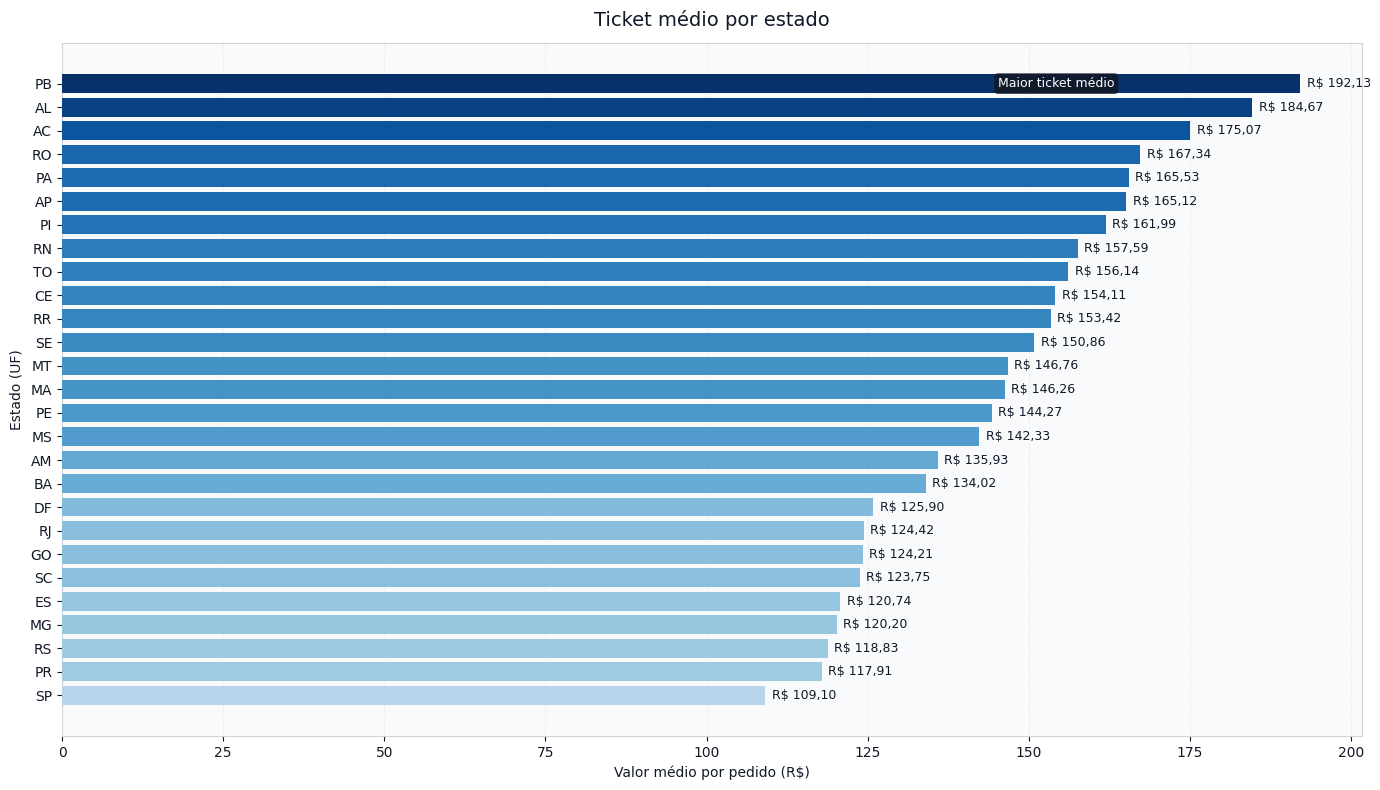

In [27]:
# ============================================================
# GRÁFICO: TICKET MÉDIO POR ESTADO
# ============================================================

import matplotlib.cm as cm
import numpy as np

# ------------------------------------------------------------
# Preparar dados
# ------------------------------------------------------------
# Converte o DataFrame Spark para pandas e ordena do maior
# ticket médio para o menor.
df_plot = ticket_medio_spark.toPandas().sort_values(
    "average_price",
    ascending=False
)

# ------------------------------------------------------------
# Criar gradiente de azul
# ------------------------------------------------------------
# Normaliza os valores entre 0 e 1 para aplicar intensidade de cor.
# Quanto maior o ticket médio, mais escuro será o azul.
valores = df_plot["average_price"]

norm = (valores - valores.min()) / (valores.max() - valores.min())

cores = cm.Blues(0.3 + 0.7 * norm)

# ------------------------------------------------------------
# Criar figura
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
bars = ax.barh(
    df_plot["customer_state"],
    df_plot["average_price"],
    color=cores,
    edgecolor="none",
    zorder=3
)

# Melhor estado no topo
ax.invert_yaxis()

# ------------------------------------------------------------
# Título e eixos
# ------------------------------------------------------------
ax.set_title(
    "Ticket médio por estado",
    fontsize=14,
    color=cor_texto,
    pad=12
)

ax.set_xlabel("Valor médio por pedido (R$)", color=cor_texto)
ax.set_ylabel("Estado (UF)", color=cor_texto)

# ------------------------------------------------------------
# Labels nas barras
# ------------------------------------------------------------
for bar in bars:
    valor = bar.get_width()

    ax.text(
        valor + 1,
        bar.get_y() + bar.get_height() / 2,
        f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."),
        va="center",
        ha="left",
        fontsize=9,
        color=cor_texto
    )

# ------------------------------------------------------------
# Destaque do estado com maior ticket médio
# ------------------------------------------------------------
top_estado = df_plot.iloc[0]

ax.text(
    top_estado["average_price"] * 0.85,
    0,
    "Maior ticket médio",
    va="center",
    ha="right",
    fontsize=9,
    color="#FFFFFF",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="#111827",
        edgecolor="none",
        alpha=0.9
    ),
    zorder=4
)

# ------------------------------------------------------------
# Grid e estilo
# ------------------------------------------------------------
ax.grid(axis="x", linestyle="--", alpha=0.3, color=cor_grid, zorder=0)

ax.tick_params(axis="x", colors=cor_texto)
ax.tick_params(axis="y", colors=cor_texto)

for spine in ax.spines.values():
    spine.set_color(cor_grid)

plt.tight_layout()
plt.show()